# Regressão Linear

<hr>

- Este é um notebook com uma implementação do algoritmo da Regressão Linear, tanto sua solução analítica quanto iterativa.


<hr>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Geração dos Dados

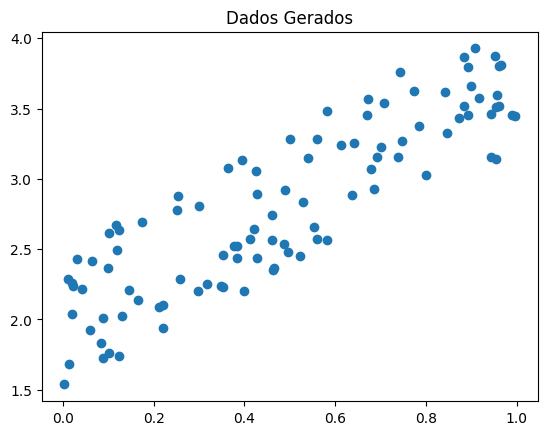

In [17]:
np.random.seed(10301411)

n_points = 100
X = np.random.rand(n_points,1)
Y = np.array([2 + 1.7*i + np.random.uniform(-0.5,0.5) for i in X])

plt.scatter(X, Y)
plt.title('Dados Gerados')
plt.show()

In [18]:
# Dataset determinístico para testes
X_test = np.array([[1, 1],
                   [1, 2],
                   [1, 3]])

y_test = np.array([[3],
                   [5],
                   [7]])

## Solução Analítica

Modelo linear:

$$
\hat{y} = Xw
$$

Queremos minimizar o erro quadrático:

$$
J(w) = \frac{1}{N}(Xw - y)^T (Xw - y)
$$

Derivando em relação a $w$:

$$
\nabla_w J = \frac{2}{N} X^T (Xw - y)
$$

Igualando a zero:

$$
X^T X w = X^T y
$$

Se $X^T X$ for invertível (supõe-se que seja):

$$
w = (X^T X)^{-1} X^T y
$$


## Implementação

In [19]:
def compute_weights(X, y):
    return np.linalg.inv(X.T @ X) @ X.T @ y

theta_test = compute_weights(X_test, y_test)

# 1. Checar shape
assert theta_test.shape == (2, 1), (
    f"Shape incorreto: esperado (2,1), obtido {theta_test.shape}"
)

# 2. Checar valores esperados (y = 1 + 1*x)
theta_expected = np.array([[1], [2]])

assert np.allclose(theta_test, theta_expected, atol=1e-6), (
    f"Valores incorretos:\n"
    f"Esperado:\n{theta_expected}\n"
    f"Obtido:\n{theta_test}"
)
print("✔ compute_weights correto!")

✔ compute_weights correto!


In [20]:
def predict(X, theta):
    return X @ theta

# teste rapido
theta_true = np.array([[1],[2]])
pred = predict(X_test, theta_true)

# 1. Checar shape
assert pred.shape == y_test.shape, (
    f"Shape incorreto: esperado {y_test.shape}, obtido {pred.shape}"
)

# 2. Checar valores
assert np.allclose(pred, y_test, atol=1e-6), (
    f"Predições incorretas:\n"
    f"Esperado:\n{y_test}\n"
    f"Obtido:\n{pred}"
)

print("✔ predict correto!")

✔ predict correto!


## Implementação Iterativa (Gradient Descent)

In [21]:
def compute_MSE(X, y, theta):
    N = X.shape[0]
    Error =  X @ theta - y
    return ((1/N) * (Error.T @ Error).item())


# teste rapido
theta_true = np.array([[1],[2]])
mse = compute_MSE(X_test, y_test, theta_true)

# 1. Checar tipo/forma (opcional mas útil)
assert np.isscalar(mse) or np.shape(mse) == (), (
    f"MSE deveria ser escalar, mas foi {type(mse)} com shape {np.shape(mse)}"
)

# 2. Checar valor esperado
assert np.isclose(mse, 0.0, atol=1e-6), (
    f"MSE incorreto: esperado ~0.0, obtido {mse}"
)

print("✔ compute_MSE correto!")


✔ compute_MSE correto!


In [10]:
def compute_gradient(X, y, theta):
    N = X.shape[0]
    return (2/N) * X.T @ (X @ theta - y)



# teste rapido
theta_true = np.array([[1],[2]])
grad = compute_gradient(X_test, y_test, theta_true)

# 1. Checar shape
assert grad.shape == theta_true.shape, (
    f"Shape incorreto: esperado {theta_true.shape}, obtido {grad.shape}"
)

# 2. Checar valores (gradiente deve ser ~0 no ótimo)
expected_grad = np.zeros_like(theta_true)

assert np.allclose(grad, expected_grad, atol=1e-6), (
    f"Gradiente incorreto:\n"
    f"Esperado:\n{expected_grad}\n"
    f"Obtido:\n{grad}"
)

print("✔ compute_gradient correto!")

✔ compute_gradient correto!


In [22]:
def gradient_descent(X, y, lr=0.1, epochs=1000):
    N, d = X.shape
    theta = np.zeros((d, 1))
    for _ in range(epochs):
        grad = compute_gradient(X, y, theta)
        theta = theta - lr * grad
    
    return theta



# teste rapido
theta_learned = gradient_descent(X_test, y_test, lr=0.1, epochs=1000)
expected = np.array([[1],[2]])

# 1. Checar shape
assert theta_learned.shape == expected.shape, (
    f"Shape incorreto: esperado {expected.shape}, obtido {theta_learned.shape}"
)

# 2. Checar convergência dos valores
assert np.allclose(theta_learned, expected, atol=1e-2), (
    f"Gradient Descent incorreto:\n"
    f"Esperado:\n{expected}\n"
    f"Obtido:\n{theta_learned}"
)

# 3. Checar se realmente minimiza o erro
mse = compute_MSE(X_test, y_test, theta_learned)

assert np.isclose(mse, 0.0, atol=1e-4), (
    f"MSE após treinamento deveria ser ~0, mas foi {mse}"
)

print("✔ gradient_descent correto!")

✔ gradient_descent correto!


## Algumas Visualizações

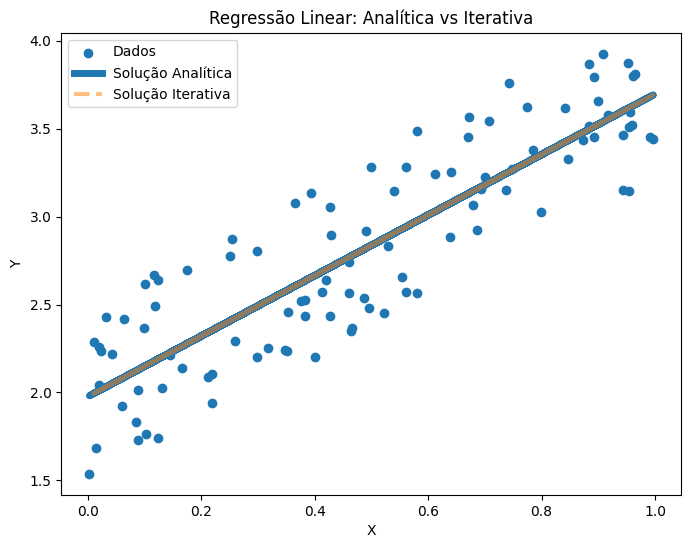

In [52]:
# ===============================
# Plot: Analítica vs Iterativa
# ===============================

# Adicionando coluna de bias (1s)
X_design = np.c_[np.ones((X.shape[0], 1)), X.reshape(-1, 1)]

# Solução analítica
theta_analitico = compute_weights(X_design, Y.reshape(-1,1))

# Solução iterativa
theta_iterativo = gradient_descent(X_design, Y.reshape(-1,1))

# Predições
y_pred_analitico = predict(X_design, theta_analitico)
y_pred_iterativo = predict(X_design, theta_iterativo)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X, Y, label="Dados")

plt.plot(X, y_pred_analitico, label="Solução Analítica", ls = '-', lw = '5')
plt.plot(X, y_pred_iterativo, label="Solução Iterativa", ls = '--', lw = '3', alpha = 0.5)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Regressão Linear: Analítica vs Iterativa")
plt.legend()

plt.show()

